<a href="https://colab.research.google.com/github/sirivalliavutu/Carbon-Footprint-Analyzer/blob/main/Module_5_Part_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Module 5
## Part 4: RAG Knowledge Systems using LangChain

## Learning Objectives
- Understand Retrieval-Augmented Generation (RAG) architecture and why it matters
- Build RAG components step-by-step: document loaders, text splitters, embeddings, vector stores
- Implement a retriever that finds relevant context for LLM queries
- Combine all components into a complete RAG agent using LangChain
- Evaluate RAG performance and iterate on retrieval strategies


## 1. What is RAG?

**Retrieval-Augmented Generation (RAG)** combines:
- **Retrieval**: Find relevant documents/chunks from a knowledge base
- **Augmentation**: Inject retrieved context into the LLM prompt
- **Generation**: LLM generates answers using both its training data and the retrieved context

### Why RAG?
- **Overcomes context limits**: LLMs have fixed context windows; RAG provides external knowledge
- **Reduces hallucinations**: Grounds answers in actual documents
- **Enables knowledge updates**: Add new documents without retraining the model
- **Domain-specific answers**: Use proprietary/internal documents

### RAG Pipeline Overview

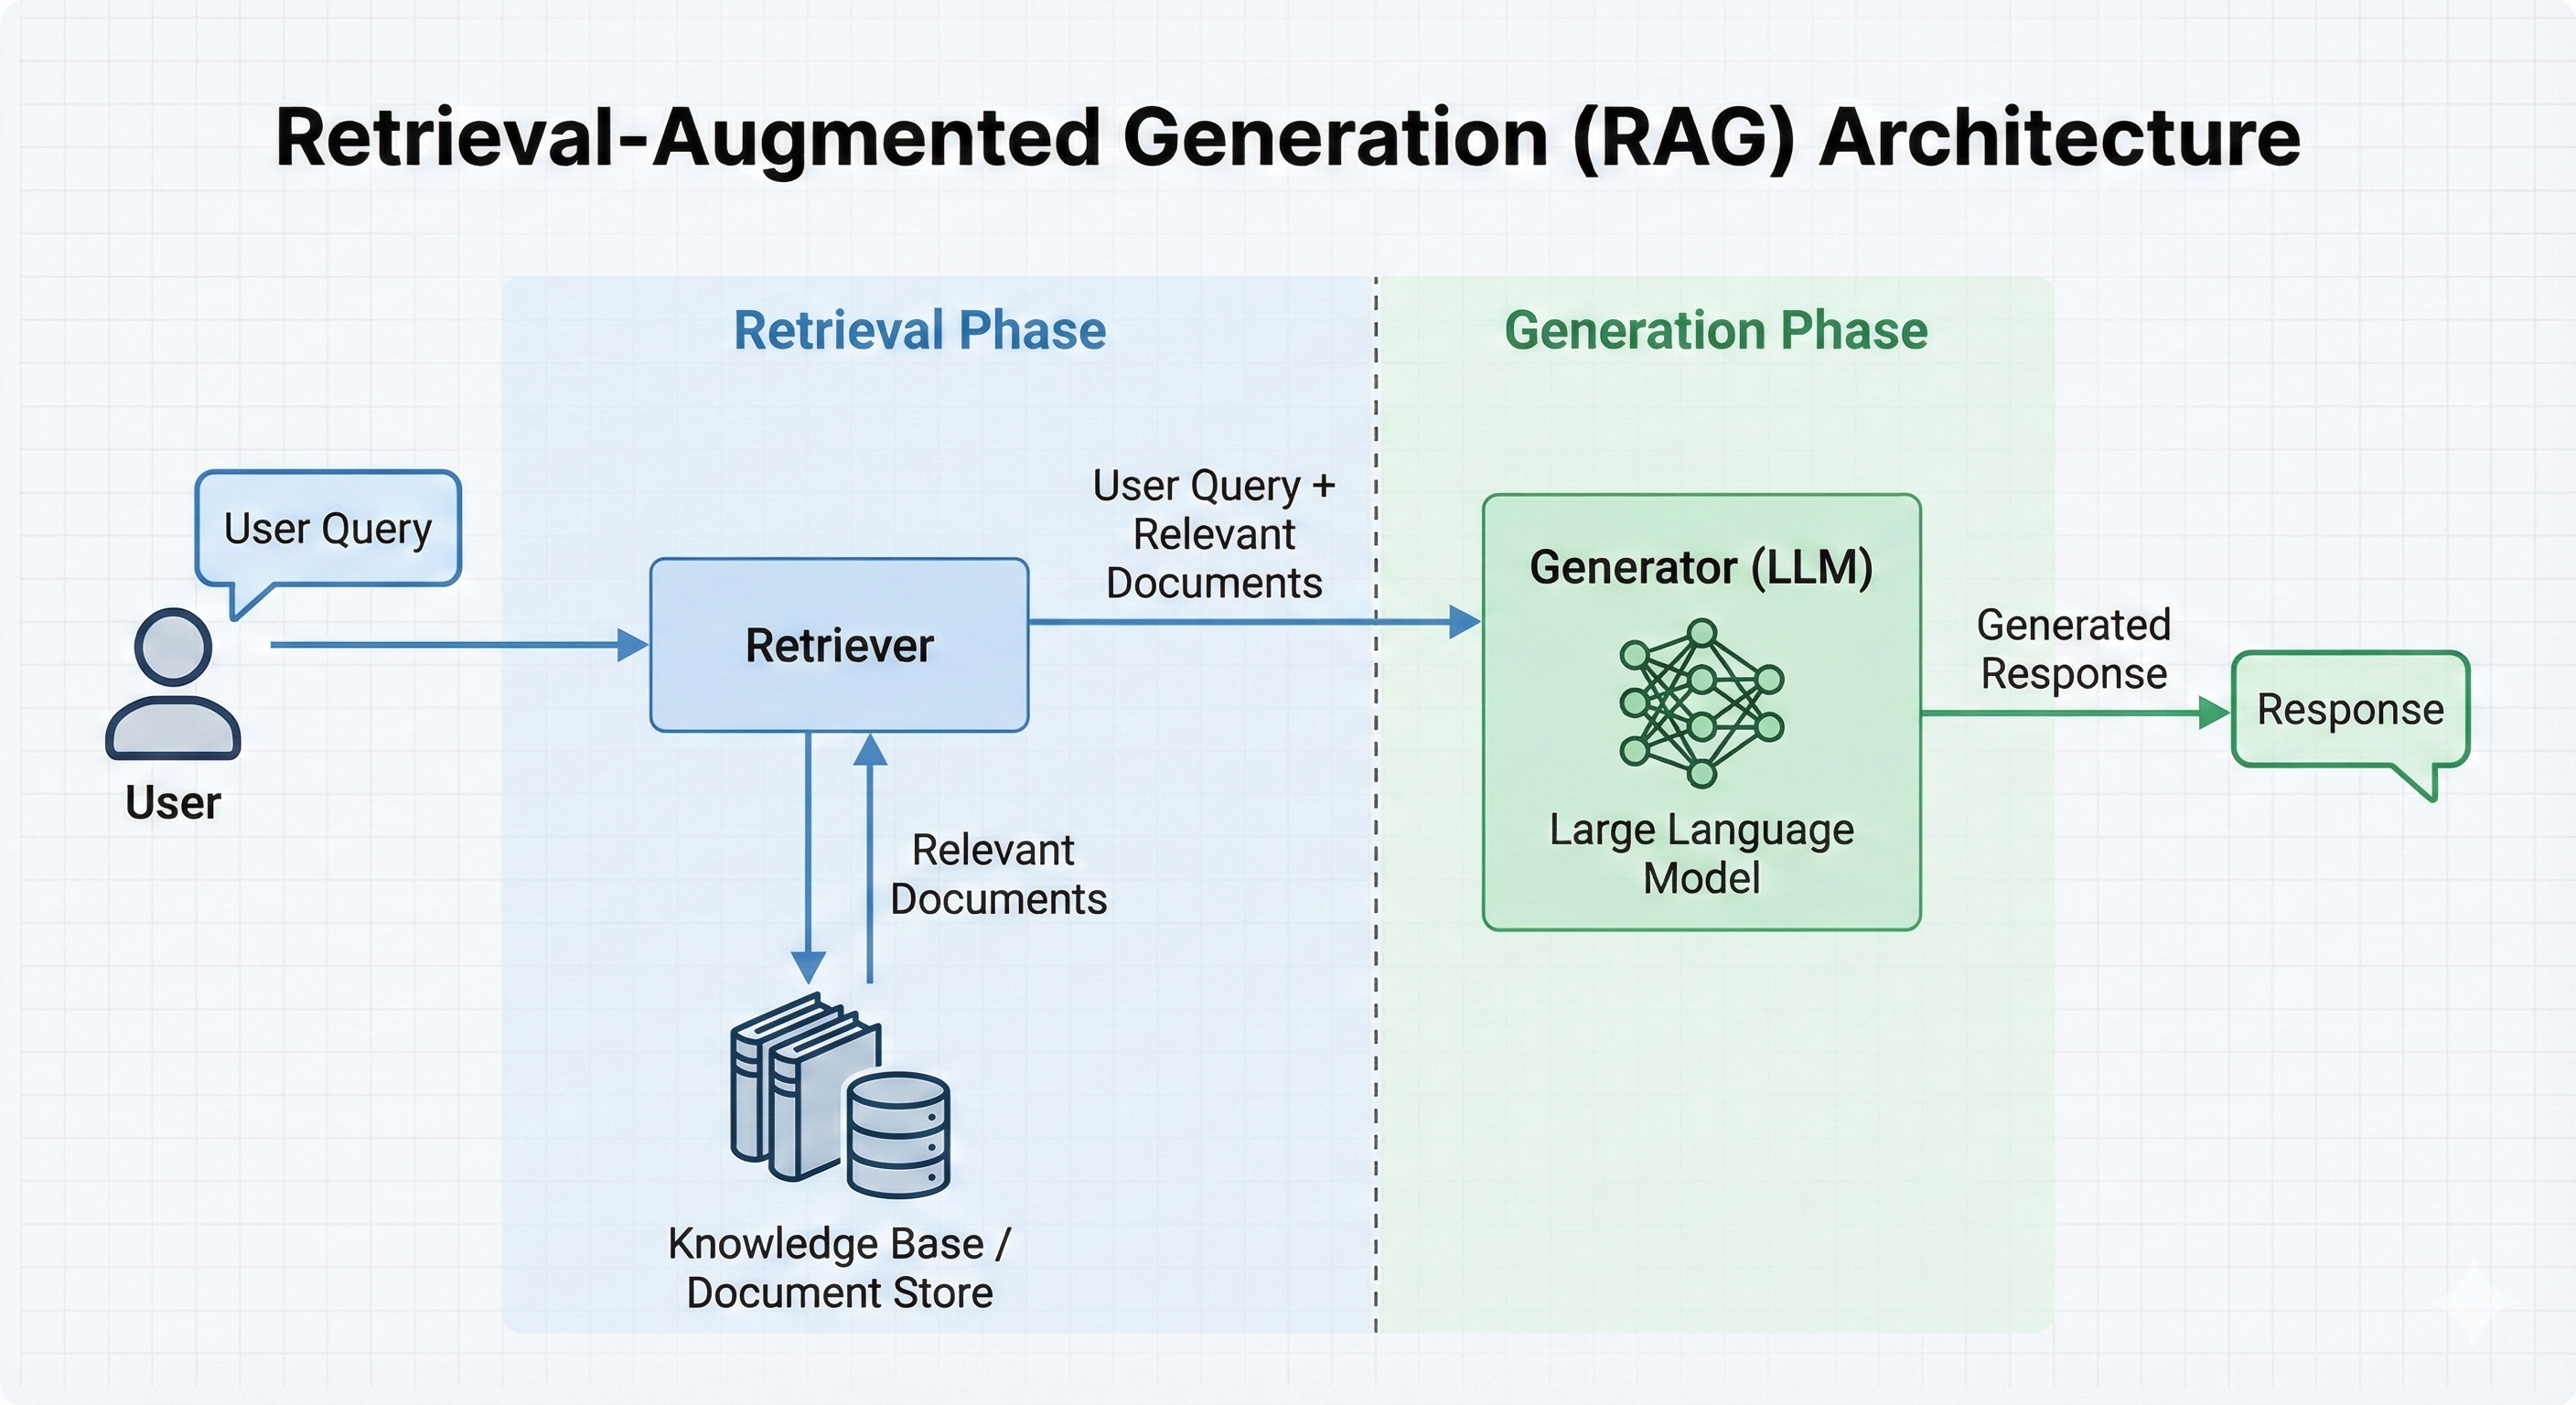

## 2. Setup


In [ ]:
!pip install langchain langchain-classic langchain-community langchain-openai langchain-text-splitters chromadb pypdf tiktoken

In [ ]:
import os
from pathlib import Path
from typing import List

# Set API key
api_key = os.environ.get("OPENAI_API_KEY", "")
if api_key.endswith("..."):
    print("⚠️ Set OPENAI_API_KEY for live demos.")
else:
    print("✅ API key configured")


## 3. Building Block 1: Document Loading

The first step is loading documents from various sources. LangChain provides loaders for:
- PDFs, Word docs, text files
- Web pages, YouTube transcripts
- Databases, APIs
- Google Drive, Notion, etc.

Let's create sample documents for our demo:


In [ ]:
# Create sample documents directory
doc_dir = Path("sample_docs")
doc_dir.mkdir(exist_ok=True)

# Sample document 1: AI Course Overview
doc1 = doc_dir / "ai_course_overview.txt"
doc1.write_text("""
Artificial Intelligence Course Overview

This course covers fundamental concepts in AI including:
- Machine Learning: Supervised, unsupervised, and reinforcement learning
- Deep Learning: Neural networks, CNNs, RNNs, and transformers
- Natural Language Processing: Tokenization, embeddings, and language models
- Computer Vision: Image classification, object detection, and segmentation

The course emphasizes hands-on projects using Python, PyTorch, and TensorFlow.
Students will build end-to-end ML pipelines and deploy models to production.
""")

# Sample document 2: RAG Techniques
doc2 = doc_dir / "rag_techniques.txt"
doc2.write_text("""
Retrieval-Augmented Generation (RAG) Techniques

RAG combines retrieval and generation to improve LLM responses:
1. Document Chunking: Split large documents into smaller, manageable chunks
2. Embedding Generation: Convert text chunks into vector embeddings
3. Vector Storage: Store embeddings in vector databases like ChromaDB or Pinecone
4. Similarity Search: Find relevant chunks using cosine similarity
5. Context Augmentation: Inject retrieved chunks into LLM prompts

Best practices:
- Use semantic chunking (by sentences/paragraphs) rather than fixed-size chunks
- Overlap chunks slightly to preserve context across boundaries
- Use metadata filtering to narrow search scope
- Implement re-ranking for better retrieval quality
""")

# Sample document 3: LangChain Basics
doc3 = doc_dir / "langchain_basics.txt"
doc3.write_text("""
LangChain Framework Basics

LangChain is a framework for building LLM applications:
- Chains: Sequential processing of LLM calls
- Agents: LLMs that can use tools and make decisions
- Memory: Maintain conversation history and context
- Retrievers: Components that fetch relevant documents

Key components:
- Document Loaders: Load data from various sources
- Text Splitters: Break documents into chunks
- Embeddings: Convert text to vectors
- Vector Stores: Store and search embeddings
- LLMs: Language models (OpenAI, Anthropic, local models)

LangChain simplifies building complex AI applications by providing reusable components.
""")

print(f"Created {len(list(doc_dir.glob('*.txt')))} sample documents")


In [ ]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader

# Load a single document
loader = TextLoader(str(doc1))
documents = loader.load()
print(f"Loaded {len(documents)} document(s)")
print(f"First document preview:\n{documents[0].page_content[:200]}...")

# Load all documents from directory
directory_loader = DirectoryLoader(
    str(doc_dir),
    glob="*.txt",
    loader_cls=TextLoader
)
all_documents = directory_loader.load()
print(f"\nTotal documents loaded: {len(all_documents)}")
for i, doc in enumerate(all_documents, 1):
    print(f"{i}. {doc.metadata.get('source', 'unknown')} ({len(doc.page_content)} chars)")


## 4. Building Block 2: Text Splitting

Documents are often too large to fit in LLM context windows. We split them into smaller **chunks**.

### Key Considerations:
- **Chunk size**: Balance between context preservation and retrieval precision
- **Chunk overlap**: Preserve context across boundaries
- **Splitting strategy**: By characters, tokens, sentences, or semantic units

Let's explore different splitting strategies:


In [ ]:
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    CharacterTextSplitter,
    TokenTextSplitter
)

# Example text to split
sample_text = all_documents[0].page_content

# Strategy 1: Recursive Character Splitter (Recommended)
# Tries to split on paragraphs, then sentences, then words
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)
recursive_chunks = recursive_splitter.split_text(sample_text)
print(f"Recursive splitter: {len(recursive_chunks)} chunks")
print(f"First chunk:\n{recursive_chunks[0]}\n")

# Strategy 2: Character Splitter (Simple)
char_splitter = CharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50,
    separator=" "
)
char_chunks = char_splitter.split_text(sample_text)
print(f"Character splitter: {len(char_chunks)} chunks")
print(f"First chunk:\n{char_chunks[0]}\n")

# Strategy 3: Token Splitter (Token-aware)
token_splitter = TokenTextSplitter(
    chunk_size=100,
    chunk_overlap=20
)
token_chunks = token_splitter.split_text(sample_text)
print(f"Token splitter: {len(token_chunks)} chunks")


In [ ]:
# Split all documents into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    length_function=len
)

# Split documents
texts = text_splitter.split_documents(all_documents)
print(f"Total chunks created: {len(texts)}")
print(f"\nSample chunk metadata: {texts[0].metadata}")
print(f"\nSample chunk content (first 150 chars):\n{texts[0].page_content[:150]}...")


## 5. Building Block 3: Embeddings

**Embeddings** convert text into dense vector representations that capture semantic meaning. Similar texts have similar embeddings.

### Embedding Models:
- **OpenAI**: `text-embedding-3-small`, `text-embedding-3-large`
- **Open-source**: Sentence Transformers (all-MiniLM-L6-v2, etc.)
- **Local**: Can run embedding models locally for privacy

Let's create embeddings for our document chunks:


In [ ]:
from langchain_openai import OpenAIEmbeddings

# Initialize embedding model
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    openai_api_key=api_key
)

# Create embeddings for a sample chunk
sample_chunk = texts[0].page_content
sample_embedding = embeddings.embed_query(sample_chunk)
print(f"Embedding dimension: {len(sample_embedding)}")
print(f"First 5 values: {sample_embedding[:5]}")

# Create embeddings for all chunks (this will be done when we add to vector store)
print(f"\n✅ Embedding model initialized. Ready to embed {len(texts)} chunks.")


## 6. Building Block 4: Vector Stores

**Vector stores** store embeddings and enable fast similarity search. Popular options:
- **ChromaDB**: Lightweight, in-memory or persistent
- **Pinecone**: Managed cloud vector database
- **FAISS**: Facebook's similarity search library
- **Weaviate**: Open-source vector database

We'll use **ChromaDB** for this demo (works great in Colab):


In [ ]:
from langchain_community.vectorstores import Chroma

# Create vector store and add documents
# This will automatically:
# 1. Generate embeddings for all chunks
# 2. Store them in ChromaDB
# 3. Enable similarity search

vectorstore = Chroma.from_documents(
    documents=texts,
    embedding=embeddings,
    persist_directory="./chroma_db"  # Optional: persist to disk
)

print(f"✅ Vector store created with {len(texts)} document chunks")
print(f"Vector store type: {type(vectorstore).__name__}")


In [ ]:
# Test similarity search
query = "What is RAG and how does it work?"
results = vectorstore.similarity_search(query, k=1)

print(f"Query: {query}\n")
print("Top 3 most relevant chunks:\n")
for i, doc in enumerate(results, 1):
    print(f"{i}. Relevance Score: {doc.metadata.get('source', 'unknown')}")
    print(f"   Content: {doc.page_content[:200]}...\n")


In [ ]:
# Get similarity search with scores
results_with_scores = vectorstore.similarity_search_with_score(query, k=3)

print(f"Query: {query}\n")
print("Top 3 results with similarity scores:\n")
for i, (doc, score) in enumerate(results_with_scores, 1):
    print(f"{i}. Score: {score:.4f} (lower = more similar)")
    print(f"   Source: {doc.metadata.get('source', 'unknown')}")
    print(f"   Content: {doc.page_content[:150]}...\n")


In [ ]:
# Basic retriever
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}  # Return top 3 results
)

# Test the retriever
query = "What are the key components of LangChain?"
retrieved_docs = retriever.invoke(query)

print(f"Query: {query}\n")
print(f"Retrieved {len(retrieved_docs)} documents:\n")
for i, doc in enumerate(retrieved_docs, 1):
    print(f"{i}. {doc.metadata.get('source', 'unknown')}")
    print(f"   {doc.page_content[:150]}...\n")


In [ ]:
# MMR Retriever (Maximal Marginal Relevance)
# Balances relevance and diversity
mmr_retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "fetch_k": 5}  # Fetch 5, return top 3 diverse results
)

print("MMR Retriever (diverse results):\n")
mmr_docs = mmr_retriever.invoke(query)
for i, doc in enumerate(mmr_docs, 1):
    print(f"{i}. {doc.metadata.get('source', 'unknown')}")
    print(f"   {doc.page_content[:150]}...\n")


## 7. Building Block 5: LLM Integration

Now we'll combine all components into a **RAG chain** that:
1. Takes a user query
2. Retrieves relevant documents
3. Augments the prompt with retrieved context
4. Generates an answer using the LLM

Let's set up the LLM:


In [ ]:
from langchain_openai import ChatOpenAI

# Initialize LLM
llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    temperature=0.2,  # Lower temperature for more factual responses
    openai_api_key=api_key
)

# Test the LLM
test_response = llm.invoke("What is 2+2?")
print(f"LLM Response: {test_response.content}")
print("✅ LLM initialized and working")


## 8. Complete RAG Chain

Now let's combine everything into a complete RAG system using LangChain's `RetrievalQA` chain:


In [ ]:
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

# Custom prompt template
system_prompt = """Use the following pieces of context to answer the question.
If you don't know the answer, just say that you don't know, don't try to make up an answer.

Context:
{context}"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}")
])

# Create document chain (handles the "stuff" approach)
document_chain = create_stuff_documents_chain(llm, prompt)

# Create RAG chain (combines retrieval + document chain)
qa_chain = create_retrieval_chain(retriever, document_chain)

print("✅ RAG chain created!")


In [ ]:
# Test the RAG chain
questions = [
    "what is RAG?",
    "What are the key components of LangChain?",
    "What does the AI course cover?"
]

for question in questions:
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print(f"{'='*60}\n")

    # NOTE: In the new chain API, use "input" instead of "query"
    result = qa_chain.invoke({"input": question})

    # NOTE: Response keys are "answer" and "context" (not "result" and "source_documents")
    print(f"Answer: {result['answer']}\n")
    print(f"Context documents used ({len(result['context'])}):")
    for i, doc in enumerate(result['context'], 1):
        print(f"  {i}. {doc.metadata.get('source', 'unknown')}")
    print()
